cuda


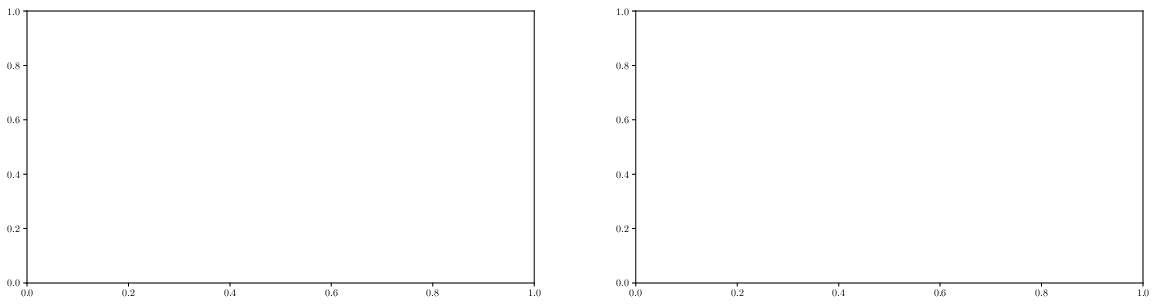

In [18]:
import os
import sys
import time
import copy
sys.path.append('..')

import numpy as np
import math
import random

import torch
import torch.nn as nn
import torch.nn.functional as F

import json

import fnmatch
import re
from itertools import product, groupby

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as mticker

device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(device)

from scipy.stats import t

def fit_powerlaw(x, y, n_bootstrap=1000, rng=None):
    """
    Fit y = a * x^alpha on log-log scale.
    Returns alpha with two error estimates:
      - se_cov:  standard error from polyfit's covariance matrix
      - se_boot: standard error from bootstrap resampling
    """
    rng = np.random.default_rng(rng)
    lx, ly = np.log(x), np.log(y)

    # ── Covariance-based SE ───────────────────────────────────────────────────
    coeffs, cov = np.polyfit(lx, ly, deg=1, cov=True)
    alpha    = coeffs[0]          # power-law exponent
    se_cov   = np.sqrt(cov[0, 0]) # SE on the slope

    # ── Bootstrap SE ─────────────────────────────────────────────────────────
    idx       = np.arange(len(x))
    boot_alphas = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample = rng.choice(idx, size=len(idx), replace=True)
        boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]

    se_boot = boot_alphas.std(ddof=1)  # ddof=1 → unbiased sample std

    return alpha, se_cov, se_boot, boot_alphas

fig, ax = plt.subplots(1, 2, figsize=(20,5.0))

## Fit early decay to power-law and plot exponent as a function of range

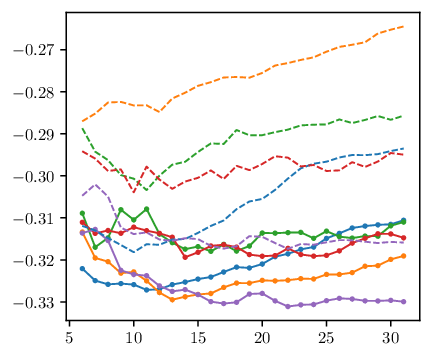

In [7]:
dataset = 'tinystories'
tokenizer = 'BPE8192'

from scipy.stats import t

matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*3.4), dpi=120)


for i, arch in enumerate(['T128_d12', 'T128_d12_mamba', 'T512_d12', 'T512_d12_rope', 'T511_llama']):

    results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.{tokenizer}_{arch}.pt")
    p_list = results['data']
    ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

    npts_list = []
    gamma_list = []

    for  end in range(6,32):

        rng = np.random.default_rng(42)
        x = np.array([i+1 for i in range(end)])
        y = np.array(ngrams_list[-1][:end])
        gamma, se_cov, se_boot, boot_dist = fit_powerlaw(x, y, rng=rng)

        npts_list.append(end)
        gamma_list.append(gamma)

    ax.plot(npts_list, gamma_list, color=f'C{i}', marker='.')

# for i, arch in enumerate(['T128_d12', 'T128_d12_mamba', 'T512_d12', 'T512_d12_rope', 'T511_llama']):

#     results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.{tokenizer}_{arch}.pt")
#     p_list = results['data']
#     ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

#     npts_list = []
#     gamma_list = []

#     for  end in range(6,32):

#         rng = np.random.default_rng(42)
#         x = np.array([i+1 for i in range(end)])
#         y = np.array(ngrams_list[-2][:end])
#         gamma, se_cov, se_boot, boot_dist = fit_powerlaw(x, y, rng=rng)

#         npts_list.append(end)
#         gamma_list.append(gamma)

#     ax.plot(npts_list, gamma_list, color=f'C{i}', linestyle='dashed')

In [4]:
dataset = 'tinystories'
tokenizer = 'BPE8192'
arch = 'T128_d12'

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.{tokenizer}_{arch}.pt")
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

In [5]:
end = 15

rng = np.random.default_rng(42)
x = np.array([i+1 for i in range(end)])
y = np.array(ngrams_list[-1][:end])
gamma, se_cov, se_boot, boot_dist = fit_powerlaw(x, y, n_bootstrap=100, rng=rng)

print(f"gamma       = {gamma:.4f}")
print(f"SE (cov)    = {se_cov:.4f}   → {gamma:.4f} ± {se_cov:.4f}")
print(f"SE (boot)   = {se_boot:.4f}  → {gamma:.4f} ± {se_boot:.4f}")

# Bootstrap also gives you percentile CIs for free (asymmetric if needed):
lo, hi = np.percentile(boot_dist, [2.5, 97.5])
print(f"95% boot CI = [{lo:.4f}, {hi:.4f}]")

gamma       = -0.3246
SE (cov)    = 0.0031   → -0.3246 ± 0.0031
SE (boot)   = 0.0032  → -0.3246 ± 0.0032
95% boot CI = [-0.3314, -0.3178]


In [6]:
end = 15

rng = np.random.default_rng(42)
x = np.array([i+1 for i in range(end)])
y = np.array(ngrams_list[-2][:end])
gamma, se_cov, se_boot, boot_dist = fit_powerlaw(x, y, n_bootstrap=100, rng=rng)

print(f"gamma       = {gamma:.4f}")
print(f"SE (cov)    = {se_cov:.4f}   → {gamma:.4f} ± {se_cov:.4f}")
print(f"SE (boot)   = {se_boot:.4f}  → {gamma:.4f} ± {se_boot:.4f}")

# Bootstrap also gives you percentile CIs for free (asymmetric if needed):
lo, hi = np.percentile(boot_dist, [2.5, 97.5])
print(f"95% boot CI = [{lo:.4f}, {hi:.4f}]")

gamma       = -0.3136
SE (cov)    = 0.0025   → -0.3136 ± 0.0025
SE (boot)   = 0.0024  → -0.3136 ± 0.0024
95% boot CI = [-0.3195, -0.3098]


tensor(3.6755)


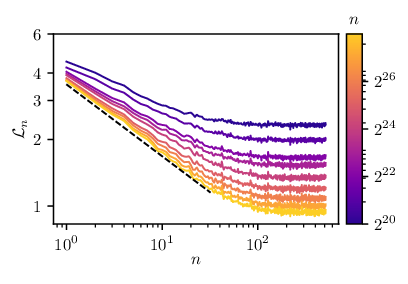

In [82]:
matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})

fig = plt.figure(figsize=(1.5*2.2, 1*2.2), dpi=120)  # can be same for all
L, B, W, H = 0.18, 0.18, 0.72, 0.72 
ax  = fig.add_axes([L, B, W, H])                # <-- plot box is fixed

dataset = 'tinystories'
tokenizer = 'BPE8192'
T = 511
arch = f'T{T}_llama'

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.{tokenizer}_{arch}.pt")
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

base = matplotlib.colormaps["plasma"]                  # purple -> yellow
cmap  = matplotlib.colors.LinearSegmentedColormap.from_list(
    "plasma_trunc", base(np.linspace(0.05, 0.9, 256))
)
norm = matplotlib.colors.LogNorm(vmin=p_list[0], vmax=p_list[-1])

A = 3.55
gamma = 0.325
beta = 0.88

for i, p in enumerate(p_list):
    ax.plot([t+1 for t in range(T)], ngrams_list[i], color=cmap(norm(p+1)), label=fr'$P={p}$')

ax.plot([t+1 for t in range(32)], [A*(t+1)**(-gamma) for t in range(32)],'k--')
print(ngrams_list[-1][0])

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylabel(r'$\mathcal{L}_{n}$', fontsize=10)
ax.set_xlabel(r'$n$', fontsize=10)

import matplotlib.ticker as mticker
ticks  = [ 1, 2, 3, 4, 6]
labels = [ "1", "2", "3", "4", "6"]  # must match length/order
ax.set_yticks(ticks)
ax.set_yticklabels(labels)
ax.yaxis.set_minor_locator(mticker.NullLocator())

sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])  # optional, keeps some mpl versions happy
CB_W  = 0.04
CB_PAD = 0.02
want_cbar = True
if want_cbar:
    cax = fig.add_axes([L + W + CB_PAD, B, CB_W, H])  # same height as ax
    cbar = fig.colorbar(sm, cax=cax)
    cbar.ax.set_title(r"$n$", fontsize=10, pad=6)
ticks = 2 ** np.arange(
    int(np.floor(np.log2(p_list[0]))),
    int(np.ceil(np.log2(p_list[-1]))), 2
)
cbar.set_ticks(ticks)
exps = np.log2(ticks).astype(int)
cbar.set_ticklabels([rf"$2^{{{e}}}$" for e in exps])

# WikiText

/tmp/ipykernel_391632/1552817908.py:52: RankWarning: Polyfit may be poorly conditioned
  boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]
/tmp/ipykernel_391632/1552817908.py:52: RankWarning: Polyfit may be poorly conditioned
  boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]
/tmp/ipykernel_391632/1552817908.py:52: RankWarning: Polyfit may be poorly conditioned
  boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]
/tmp/ipykernel_391632/1552817908.py:52: RankWarning: Polyfit may be poorly conditioned
  boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]
/tmp/ipykernel_391632/1552817908.py:52: RankWarning: Polyfit may be poorly conditioned
  boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]
/tmp/ipykernel_391632/1552817908.py:52: RankWarning: Polyfit may be poorly conditioned
  boot_alphas[i] = np.polyfit(lx[sample], ly[sample], deg=1)[0]
/tmp/ipykernel_391632/1552817908.py:52: RankWarning: Polyfit may be poorly conditioned
  boot_

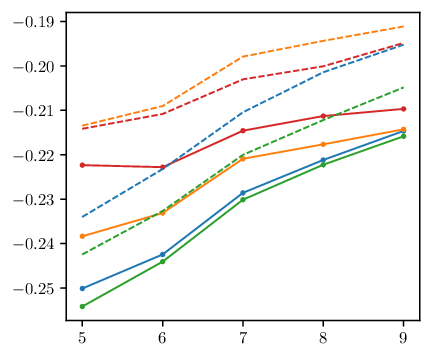

In [13]:
dataset = 'wikitext'
tokenizer = 'BPE8192'

from scipy.stats import t

matplotlib.use("pgf")
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'text.usetex': True,
    'pgf.rcfonts': False,
    'font.size': 10,
    'lines.markersize': 4,
    'lines.linewidth': 1.0,
})
# fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*2.4), dpi=120)
fig, ax = plt.subplots(1, 1, figsize=(1*3.8, 1*3.4), dpi=120)


for i, arch in enumerate(['T128_d12', 'T512_d12', 'T128_d12_rope', 'T512_d12_rope']):

    results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.{tokenizer}_{arch}.pt")
    p_list = results['data']
    ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

    npts_list = []
    gamma_list = []

    for  end in range(5,10):

        rng = np.random.default_rng(42)
        x = np.array([i+1 for i in range(end)])
        y = np.array(ngrams_list[-1][:end])
        gamma, se_cov, se_boot, boot_dist = fit_powerlaw(x, y, rng=rng)

        npts_list.append(end)
        gamma_list.append(gamma)

    ax.plot(npts_list, gamma_list, color=f'C{i}', marker='.')

for i, arch in enumerate(['T128_d12', 'T512_d12', 'T128_d12_rope', 'T512_d12_rope']):

    results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.{tokenizer}_{arch}.pt")
    p_list = results['data']
    ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

    npts_list = []
    gamma_list = []

    for  end in range(5,10):

        rng = np.random.default_rng(42)
        x = np.array([i+1 for i in range(end)])
        y = np.array(ngrams_list[-2][:end])
        gamma, se_cov, se_boot, boot_dist = fit_powerlaw(x, y, rng=rng)

        npts_list.append(end)
        gamma_list.append(gamma)

    ax.plot(npts_list, gamma_list, color=f'C{i}', linestyle='dashed')

In [15]:
dataset = 'wikitext'
tokenizer = 'BPE8192'
arch = 'T128_d12'

results = torch.load(f"{dataset}/learning-curves/ngrams_{dataset}.{tokenizer}_{arch}.pt")
p_list = results['data']
ngrams_list = [n.mean(dim=0) for n in results['ngrams']]

In [17]:
end = 5

rng = np.random.default_rng(42)
x = np.array([i+1 for i in range(end)])
y = np.array(ngrams_list[-1][:end])
gamma, se_cov, se_boot, boot_dist = fit_powerlaw(x, y, n_bootstrap=100, rng=rng)

print(f"gamma       = {gamma:.4f}")
print(f"SE (cov)    = {se_cov:.4f}   → {gamma:.4f} ± {se_cov:.4f}")
print(f"SE (boot)   = {se_boot:.4f}  → {gamma:.4f} ± {se_boot:.4f}")

# Bootstrap also gives you percentile CIs for free (asymmetric if needed):
lo, hi = np.percentile(boot_dist, [2.5, 97.5])
print(f"95% boot CI = [{lo:.4f}, {hi:.4f}]")

gamma       = -0.2501
SE (cov)    = 0.0069   → -0.2501 ± 0.0069
SE (boot)   = 0.0127  → -0.2501 ± 0.0127
95% boot CI = [-0.2654, -0.2129]
